<a href="https://colab.research.google.com/github/avionerman/neural-networks-msc/blob/main/%5BREPORT%5D%20food_CLIP_ViT_BLIP_LoRA_FAISS_RAG_CLAUDE_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# coding: utf-8
# ============================================================================
# CELL 1/2 - SETUP. Παραγει ολα τα γραφηματα απο το JSON και τα αποθηκευει
# στον φακελο report_figures/. Τρεξτε αυτο πρωτο, μια φορα.
# ============================================================================

import json, os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Δεδομενα (inlined απο το s2_results_extended.json) -------------------
RESULTS = {
  "metadata": {
    "task": "Food-101 Visual RAG (CLIP retrieval + BLIP generation + Claude augmenter)",
    "clip_checkpoint": "openai/clip-vit-base-patch32",
    "blip_checkpoint": "Salesforce/blip-image-captioning-base",
    "claude_model": "claude-haiku-4-5",
    "num_classes": 101, "gallery_size": 10100, "query_size": 1010, "top_k": 5,
    "lora_config": {"r": 8, "alpha": 16, "dropout": 0.05, "epochs": 1, "train_size": 2000},
    "timestamp": "2026-05-04T20:41:34.405468"
  },
  "retrieval": {
    "Recall@1": 0.7623762376237624, "Recall@5": 0.9148514851485149,
    "Recall@10": 0.9574257425742574, "map_at_10": 0.7563348980589668,
    "mrr": 0.8267774634606319,
    "per_class_top1_accuracy": {
      "55": 0.9, "88": 1.0, "70": 0.9, "58": 0.7, "22": 0.5, "2": 0.8, "41": 0.5,
      "68": 1.0, "71": 0.8, "67": 0.7, "17": 1.0, "20": 0.8, "64": 0.7, "4": 0.7,
      "84": 0.5, "12": 0.6, "8": 0.6, "33": 1.0, "90": 0.8, "52": 0.9, "16": 0.8,
      "73": 0.7, "87": 0.7, "75": 0.9, "23": 0.8, "56": 0.6, "32": 0.7, "42": 0.7,
      "54": 1.0, "7": 0.9, "91": 0.9, "93": 0.4, "46": 0.6, "50": 0.9, "98": 0.4,
      "9": 0.8, "18": 0.9, "30": 0.9, "89": 0.7, "76": 0.8, "69": 0.9, "45": 1.0,
      "36": 0.9, "81": 0.7, "39": 0.6, "37": 0.5, "95": 0.7, "0": 0.6, "1": 0.6,
      "60": 0.9, "97": 0.8, "35": 0.6, "3": 0.9, "61": 0.9, "83": 0.8, "38": 0.9,
      "15": 0.3, "14": 0.8, "79": 0.6, "27": 0.9, "53": 0.9, "85": 0.8, "82": 0.8,
      "29": 1.0, "80": 0.9, "63": 0.9, "94": 1.0, "65": 0.8, "24": 0.9, "19": 0.9,
      "28": 0.7, "10": 0.9, "74": 0.8, "40": 0.9, "31": 0.7, "5": 0.6, "100": 0.7,
      "78": 0.8, "34": 0.9, "25": 0.9, "13": 0.9, "44": 0.9, "43": 0.6, "96": 0.9,
      "62": 0.6, "51": 0.6, "59": 0.8, "6": 0.9, "48": 0.7, "99": 0.5, "57": 0.6,
      "26": 0.4, "47": 0.5, "77": 0.3, "49": 0.9, "92": 1.0, "66": 0.7, "72": 1.0,
      "86": 1.0, "21": 0.3, "11": 0.7
    },
    "hardest_5_classes": [
      {"class": "ceviche", "accuracy": 0.3}, {"class": "pork_chop", "accuracy": 0.3},
      {"class": "chocolate_cake", "accuracy": 0.3}, {"class": "steak", "accuracy": 0.4},
      {"class": "tiramisu", "accuracy": 0.4}
    ],
    "easiest_5_classes": [
      {"class": "cup_cakes", "accuracy": 1.0}, {"class": "strawberry_shortcake", "accuracy": 1.0},
      {"class": "spring_rolls", "accuracy": 1.0}, {"class": "pancakes", "accuracy": 1.0},
      {"class": "sashimi", "accuracy": 1.0}
    ]
  },
  "caption_proxy": {
    "n": 50, "no_rag_class_hit": 0.1, "rag_vote_class_hit": 0.84,
    "rag_llm_class_hit": 0.58, "seconds": 60.5666127204895,
    "caption_statistics_by_mode": {
      "none": {"mean_length": 8.8, "median_length": 9.0, "min_length": 4, "max_length": 13,
               "unique_tokens": 66, "examples": ["a hot dog with mustard on a white plate",
                "a plastic container filled with green leaves on top of a table",
                "a white bowl filled with noodles and meat"]},
      "vote": {"mean_length": 14.7, "median_length": 14.0, "min_length": 9, "max_length": 28,
               "unique_tokens": 100, "examples": ["a photo of hot dog, which is served on a white plate",
                "a photo of seaweed salad, which is part of a healthy diet",
                "a photo of pad thai, which is one of the most popular dishes in bangkok"]},
      "llm": {"mean_length": 16.033333333333335, "median_length": 15.0, "min_length": 9,
              "max_length": 47, "unique_tokens": 165,
              "examples": ["a delicious hot dog served on a white plate",
                "this appetizing seaweed salad features seaweed and seaweed as well as it is",
                "this delicious plate of pad thai features chicken, noodles, and vegetables"]}
    }
  },
  "lora_comparison": {"base_none": 0.1, "base_vote": 0.84, "base_llm": 0.56,
                      "lora_none": 0.46, "lora_vote": 0.84, "lora_llm": 0.6},
  "config": {"clip_ckpt": "openai/clip-vit-base-patch32",
             "blip_ckpt": "Salesforce/blip-image-captioning-base",
             "claude_model": "claude-haiku-4-5",
             "n_gallery": 10100, "n_query": 1010, "k": 5}
}

Path("s2_results_extended.json").write_text(
    json.dumps(RESULTS, ensure_ascii=False, indent=2), encoding="utf-8")

FIG_DIR = Path("report_figures"); FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "figure.facecolor": "white", "axes.spines.top": False, "axes.spines.right": False,
})

def save(fig, fname):
    path = FIG_DIR / fname
    fig.savefig(path, dpi=120, bbox_inches="tight", facecolor="white")
    plt.close(fig); print(f"  [+] {path}")

def make_pipeline_diagram():
    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.set_xlim(0, 11); ax.set_ylim(0, 4); ax.axis("off")
    boxes = [
        (0.2, "εικονα\nquery",                "#E0F2F1", 0.9, 2.2),
        (1.6, "CLIP\n(frozen)\n512-D embed",  "#2E86AB", 1.7, 2.2),
        (4.1, "FAISS\nindex\n10,100 vectors", "#3FA7D6", 1.7, 2.2),
        (6.6, "Augmenter\nnone | vote | llm", "#F4A259", 1.9, 2.2),
        (9.0, "BLIP\n(+ LoRA?)\ncaption",     "#5BBA6F", 1.7, 2.2),
    ]
    for x, label, color, w, h in boxes:
        rect = mpatches.FancyBboxPatch((x, 1.3), w, h, boxstyle="round,pad=0.08",
            linewidth=1.2, edgecolor="#333", facecolor=color, alpha=0.85)
        ax.add_patch(rect)
        textcolor = "white" if color in ("#2E86AB","#3FA7D6","#F4A259","#5BBA6F") else "#222"
        ax.text(x+w/2, 1.3+h/2, label, ha="center", va="center",
                fontsize=10, fontweight="bold", color=textcolor)
    for s, e, lab in zip([1.1, 3.3, 5.8, 8.5], [1.6, 4.1, 6.6, 9.0],
                          ["", "top-K=5", "prompt prefix", ""]):
        ax.annotate("", xy=(e, 2.4), xytext=(s, 2.4),
                    arrowprops=dict(arrowstyle="->", lw=2, color="#444"))
        if lab:
            ax.text((s+e)/2, 2.7, lab, ha="center", fontsize=9, color="#666", style="italic")
    ax.text(9.0+1.7/2, 0.6, "FINAL CAPTION", ha="center", fontsize=11,
            fontweight="bold", color="#2E86AB",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#E0F2F1", edgecolor="#2E86AB"))
    ax.annotate("", xy=(9.0+1.7/2, 0.95), xytext=(9.0+1.7/2, 1.3),
                arrowprops=dict(arrowstyle="->", lw=2, color="#444"))
    ax.set_title("Αρχιτεκτονικη του RAG pipeline", fontsize=13, fontweight="bold", pad=4)
    save(fig, "00_pipeline_diagram.png")

def make_retrieval_metrics():
    r = RESULTS["retrieval"]
    metrics = ["Recall@1", "Recall@5", "Recall@10", "mAP@10", "MRR"]
    values  = [r["Recall@1"], r["Recall@5"], r["Recall@10"], r["map_at_10"], r["mrr"]]
    fig, ax = plt.subplots(figsize=(8.4, 3.6))
    bars = ax.bar(metrics, values, color=["#2E86AB","#3FA7D6","#5BBA6F","#F4A259","#BC4749"], edgecolor="white")
    for b, v in zip(bars, values):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_ylim(0, 1.05); ax.set_ylabel("Score (0-1)")
    ax.set_title("CLIP Retrieval - Συνολικες Μετρικες (1010 queries)")
    ax.yaxis.grid(True, linestyle=":", alpha=0.4); ax.set_axisbelow(True)
    save(fig, "01_retrieval_metrics.png")

def make_hardest_easiest():
    r = RESULTS["retrieval"]
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.7))
    for ax, key, color, title in [
        (axes[0], "hardest_5_classes", "#BC4749", "5 δυσκολοτερες κλασεις (top-1 accuracy)"),
        (axes[1], "easiest_5_classes", "#5BBA6F", "5 ευκολοτερες κλασεις (top-1 accuracy)"),
    ]:
        names = [d["class"].replace("_"," ") for d in r[key]]
        vals  = [d["accuracy"] for d in r[key]]
        bars = ax.barh(names, vals, color=color)
        ax.set_xlim(0, 1.05); ax.set_xlabel("Accuracy"); ax.set_title(title); ax.invert_yaxis()
        for b, v in zip(bars, vals):
            ax.text(v+0.01, b.get_y()+b.get_height()/2, f"{v:.0%}", va="center", fontsize=10)
    fig.tight_layout(); save(fig, "02_hardest_easiest.png")

def make_per_class_distribution():
    accs = list(RESULTS["retrieval"]["per_class_top1_accuracy"].values())
    fig, ax = plt.subplots(figsize=(8.4, 3.4))
    ax.hist(accs, bins=np.arange(0.0, 1.05, 0.1), color="#2E86AB", edgecolor="white")
    mean_v = np.mean(accs)
    ax.axvline(mean_v, color="#BC4749", linestyle="--", linewidth=2, label=f"μεσος ορος = {mean_v:.2f}")
    ax.set_xlabel("Top-1 accuracy (ανα κλαση)"); ax.set_ylabel("Πληθος κλασεων")
    ax.set_title("Κατανομη Per-Class Top-1 Accuracy (101 κλασεις)")
    ax.legend(); ax.yaxis.grid(True, linestyle=":", alpha=0.4); ax.set_axisbelow(True)
    save(fig, "03_per_class_histogram.png")

# --- 4. Accuracy buckets (horizontal bars - clean & readable) -------------
def make_accuracy_buckets():
    r = RESULTS["retrieval"]
    accs = np.array(list(r["per_class_top1_accuracy"].values()))
    n_total = len(accs)
    buckets = [
        ("0-39%   (κακη)",       int((accs <  0.4).sum()),                          "#BC4749"),
        ("40-59% (μετρια)",      int(((accs >= 0.4) & (accs < 0.6)).sum()),         "#F4A259"),
        ("60-79% (καλη)",        int(((accs >= 0.6) & (accs < 0.8)).sum()),         "#FFD166"),
        ("80-99% (πολυ καλη)",   int(((accs >= 0.8) & (accs <= 0.99)).sum()),       "#5BBA6F"),
        ("100%   (τελεια)",      int((accs >= 1.0).sum()),                          "#2E86AB"),
    ]
    names  = [b[0] for b in buckets]
    counts = [b[1] for b in buckets]
    colors = [b[2] for b in buckets]

    fig, ax = plt.subplots(figsize=(9.0, 3.8))
    bars = ax.barh(names, counts, color=colors, edgecolor="white")
    for b, c in zip(bars, counts):
        pct = c / n_total * 100
        ax.text(b.get_width() + 0.6, b.get_y() + b.get_height()/2,
                f"{c} κλασεις  ({pct:.0f}%)",
                va="center", fontsize=11, fontweight="bold", color="#333")
    ax.set_xlim(0, max(counts) * 1.22)
    ax.invert_yaxis()
    ax.set_xlabel("Πληθος κλασεων (συνολο: 101)")
    ax.set_title("Κατανομη των 101 κλασεων ανα ζωνη top-1 accuracy")
    ax.xaxis.grid(True, linestyle=":", alpha=0.4)
    ax.set_axisbelow(True)
    fig.tight_layout()
    save(fig, "04_accuracy_buckets.png")


def make_caption_class_hit():
    cp = RESULTS["caption_proxy"]
    modes = ["none", "vote", "llm"]
    vals  = [cp["no_rag_class_hit"], cp["rag_vote_class_hit"], cp["rag_llm_class_hit"]]
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    bars = ax.bar(modes, vals, color=["#999", "#2E86AB", "#F4A259"], edgecolor="white")
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.0%}", ha="center", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.0); ax.set_ylabel("Class hit-rate (proxy για ποιοτητα caption)")
    ax.set_title(f"Augmentation strategies (n={cp['n']} queries) - Base BLIP")
    ax.yaxis.grid(True, linestyle=":", alpha=0.4); ax.set_axisbelow(True)
    save(fig, "05_augmentation_comparison.png")

def make_lora_comparison():
    lc = RESULTS["lora_comparison"]
    modes = ["none", "vote", "llm"]
    base  = [lc["base_none"], lc["base_vote"], lc["base_llm"]]
    lora  = [lc["lora_none"], lc["lora_vote"], lc["lora_llm"]]
    x = np.arange(len(modes)); w = 0.36
    fig, ax = plt.subplots(figsize=(8, 3.7))
    b1 = ax.bar(x-w/2, base, w, label="BLIP base",   color="#999",    edgecolor="white")
    b2 = ax.bar(x+w/2, lora, w, label="BLIP + LoRA", color="#2E86AB", edgecolor="white")
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                    f"{b.get_height():.0%}", ha="center", fontsize=10, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(modes); ax.set_ylim(0, 1.0)
    ax.set_ylabel("Class hit-rate")
    ax.set_title("Phase 9 - LoRA fine-tuning vs base BLIP, στα 3 augmentation modes")
    ax.legend(loc="upper left"); ax.yaxis.grid(True, linestyle=":", alpha=0.4); ax.set_axisbelow(True)
    save(fig, "06_lora_grouped_bars.png")

def make_lora_heatmap():
    lc = RESULTS["lora_comparison"]
    matrix = np.array([
        [lc["base_none"], lc["base_vote"], lc["base_llm"]],
        [lc["lora_none"], lc["lora_vote"], lc["lora_llm"]],
    ])
    fig, ax = plt.subplots(figsize=(7.5, 3.0))
    im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(["none","vote","llm"])
    ax.set_yticks(range(2)); ax.set_yticklabels(["Base BLIP", "BLIP + LoRA"])
    for i in range(2):
        for j in range(3):
            ax.text(j, i, f"{matrix[i,j]:.0%}", ha="center", va="center",
                    color="black", fontsize=14, fontweight="bold")
    ax.set_title("Heatmap - 6 σεναρια (modes x BLIP variants)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Class hit-rate")
    fig.tight_layout(); save(fig, "07_lora_heatmap.png")

def make_caption_lengths():
    stats = RESULTS["caption_proxy"]["caption_statistics_by_mode"]
    modes = ["none", "vote", "llm"]
    means = [stats[m]["mean_length"] for m in modes]
    uniqs = [stats[m]["unique_tokens"] for m in modes]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    for ax, vals, title, fmt in [
        (axes[0], means, "Μεσο μηκος caption (λεξεις)", "{:.1f}"),
        (axes[1], uniqs, "Unique tokens (ποικιλια λεξιλογιου)", "{}"),
    ]:
        ax.bar(modes, vals, color=["#999","#2E86AB","#F4A259"], edgecolor="white")
        offset = max(vals)*0.02
        for i, v in enumerate(vals):
            ax.text(i, v+offset, fmt.format(v), ha="center", fontsize=11, fontweight="bold")
        ax.set_title(title); ax.set_ylim(0, max(vals)*1.2)
        ax.yaxis.grid(True, linestyle=":", alpha=0.4); ax.set_axisbelow(True)
    fig.tight_layout(); save(fig, "08_caption_length_vocab.png")

def make_scoreboard():
    ret = RESULTS["retrieval"]; cp = RESULTS["caption_proxy"]; lc = RESULTS["lora_comparison"]
    fig = plt.figure(figsize=(11.5, 4.3))
    gs = fig.add_gridspec(1, 4, wspace=0.45)
    cards = [
        ("Recall@5",                f"{ret['Recall@5']*100:.1f}%",
         "CLIP frozen retriever",       "#2E86AB"),
        ("Best caption\nclass-hit", f"{max(cp['rag_vote_class_hit'], cp['rag_llm_class_hit'])*100:.0f}%",
         "vote RAG (zero cost)",        "#5BBA6F"),
        ("LoRA gain\nστο no-RAG",   f"+{(lc['lora_none']-lc['base_none'])*100:.0f} pp",
         "10% -> 46%",                  "#F4A259"),
        ("MRR",                     f"{ret['mrr']:.3f}",
         "θεση ~1.21 για σωστη κλαση", "#BC4749"),
    ]
    for i, (title, value, sub, color) in enumerate(cards):
        ax = fig.add_subplot(gs[0, i]); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
        rect = mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96, boxstyle="round,pad=0.02",
            facecolor=color, alpha=0.92, edgecolor="white", linewidth=2)
        ax.add_patch(rect)
        ax.text(0.5, 0.78, title, ha="center", va="center", fontsize=12, fontweight="bold", color="white")
        ax.text(0.5, 0.45, value, ha="center", va="center", fontsize=26, fontweight="bold", color="white")
        ax.text(0.5, 0.18, sub,   ha="center", va="center", fontsize=10, color="white", style="italic")
    fig.suptitle("Συνοπτικος πινακας αποτελεσματων", fontsize=14, fontweight="bold", y=1.02)
    save(fig, "09_scoreboard.png")

print("[*] Παραγωγη γραφηματων ...")
make_pipeline_diagram(); make_retrieval_metrics(); make_hardest_easiest()
make_per_class_distribution(); make_accuracy_buckets(); make_caption_class_hit()
make_lora_comparison(); make_lora_heatmap(); make_caption_lengths(); make_scoreboard()
print(f"\n[OK] Αποθηκευτηκαν {len(list(FIG_DIR.glob('*.png')))} γραφηματα στο '{FIG_DIR}/'")
print("     Τωρα τρεξτε το επομενο cell (το report).")


[*] Παραγωγη γραφηματων ...
  [+] report_figures/00_pipeline_diagram.png
  [+] report_figures/01_retrieval_metrics.png
  [+] report_figures/02_hardest_easiest.png
  [+] report_figures/03_per_class_histogram.png
  [+] report_figures/04_accuracy_buckets.png
  [+] report_figures/05_augmentation_comparison.png
  [+] report_figures/06_lora_grouped_bars.png
  [+] report_figures/07_lora_heatmap.png
  [+] report_figures/08_caption_length_vocab.png
  [+] report_figures/09_scoreboard.png

[OK] Αποθηκευτηκαν 10 γραφηματα στο 'report_figures/'
     Τωρα τρεξτε το επομενο cell (το report).


# Report


## 1. Στοχος της εργασιας

Η εργασια υλοποιει ενα **Retrieval-Augmented Generation (RAG)** συστημα για **αυτοματη παραγωγη περιγραφων (image captioning)** πανω σε εικονες φαγητου απο το dataset **Food-101** (101 κλασεις, 10,100 εικονες στο gallery, 1,010 εικονες στο query set).

Το ερωτημα που απανταμε ειναι: **μπορουμε να χρησιμοποιησουμε εναν retriever (CLIP) ωστε οι περιγραφες που δινει ενα captioning μοντελο (BLIP) να γινουν πιο συγκεκριμενες;** Πιο αναλυτικα, βαζουμε τρια ερωτηματα:

1. Ποσο καλα βρισκει το **CLIP** (frozen, χωρις fine-tuning) τις ομοιες εικονες μεσα σε ενα gallery 10K+ εικονων;
2. Πως συγκρινεται μια απλη **vote** στρατηγικη με εναν **LLM augmenter** (Claude Haiku 4.5) που γραφει context-aware prompts;
3. Ποσο καλα αποδιδει ενα parameter-efficient fine-tuning (**LoRA**) του BLIP σε συγκριση με το plain RAG;

Το pipeline χρησιμοποιει τρια state-of-the-art vision-language μοντελα που δουλευουν μαζι, το καθενα στον δικο του ρολο: **CLIP** (retriever), **Claude Haiku** (LLM augmenter) και **BLIP** (captioner). Η συγκριση αναμεσα στους 6 συνδυασμους που προκυπτουν (3 augmentation modes x 2 BLIP variants - με και χωρις LoRA) δινει μια πλουσια εικονα για το που αποδιδει καλυτερα η καθε συνιστωσα.

---

## 2. Pipeline - το RAG βημα προς βημα



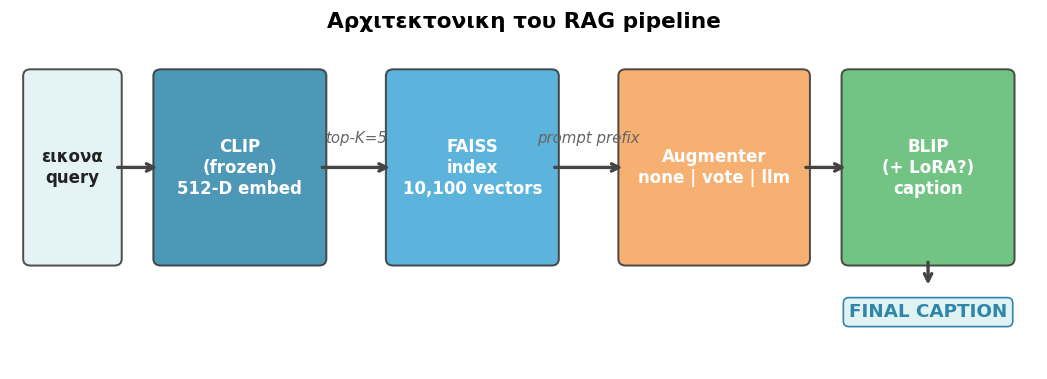


### Συνιστωσες

- **R - Retrieval**: `openai/clip-vit-base-patch32`. Encoder εικονας + κειμενου στον ιδιο χωρο 512-D. Frozen, χωρις fine-tuning.
- **A - Augmentation** (3 στρατηγικες):
  - **none**: κανενα prompt prefix - το BLIP γραφει ελευθερα.
  - **vote**: deterministic - επιλεγουμε την πιο συχνη κλαση απο τα top-5 -> prompt `"a photo of {class}, which is"`. Απλο, χωρις API call.
  - **llm**: καλουμε το **claude-haiku-4-5** με τα 5 labels + scores. Γραφει prompt που προσαρμοζεται στο ποσο συμφωνουν τα retrievals.
- **G - Generation**: `Salesforce/blip-image-captioning-base` (~247M params). Συμπληρωνει το prompt βλεποντας την εικονα.
- **Bonus - LoRA fine-tuning**: r=8, alpha=16, dropout=0.05, training σε 2,000 ζευγαρια (image, "a photo of {class}") για 1 epoch. Μονο **~590K παραμετροι** αντι για 247M (0.24% του μοντελου).

---

## 3. Ροη του notebook (13 φασεις)

| Φαση | Τι κανει | Διαρκεια |
|------|----------|----------|
| 1-2  | Setup + Food-101 download (gallery 10,100 / query 1,010) | 3-5 min |
| 3-4  | CLIP load + FAISS index (10,100 embeddings) | 30-60 sec |
| 5    | Retrieval evaluation (Recall@K) | 30-60 sec |
| 6-7  | BLIP + Claude load + η συναρτηση caption() (3 modes) | <30 sec |
| 8    | Class-hit metric πανω σε 50 samples x 3 modes | ~1 min |
| 9    | LoRA training (2,000 pairs) + 6-way eval | ~1 min |
| 10   | Full demo (retrieval + 3 captions + text query) | <30 sec |
| 11-13| Αποθηκευση metrics + JSON εξαγωγη | λιγο |

---

## 4. Αποτελεσματα - ποσο καλα αποδιδει το συστημα;

### 4.1 CLIP Retrieval (Phase 5 + Phase 12)

Το CLIP ειναι **frozen** (χωρις fine-tuning). Το αξιολογησαμε σε 1,010 queries. Οι μετρικες:

| Μετρικη | Τιμη | Τι σημαινει |
|---------|------|-------------|
| **Recall@1** | **0.7624** (76.2%) | Για το 76.2% των queries, η **μια και μονη** πιο ομοια εικονα ειναι σωστης κλασης |
| **Recall@5** | **0.9149** (91.5%) | Σχεδον **9 στους 10** queries εχουν τη σωστη κλαση μεσα στο top-5 |
| **Recall@10** | **0.9574** (95.7%) | Στο top-10, το 95.7% των queries καλυπτεται |
| **mAP@10** | **0.7563** | Πιο αυστηρη μετρικη - λαμβανει υποψη και τη σειρα των retrievals |
| **MRR** | **0.8268** | Η σωστη κλαση εμφανιζεται κατα μεσο ορο στη θεση ~1.21 |

**Συμπερασμα:** το CLIP frozen ειναι πολυ δυνατο out-of-the-box για το Food-101. Φτανει για τον retrieval ρολο χωρις κανενα fine-tuning, και δινει στο RAG χρησιμη πληροφορια σε 9 στους 10 queries.



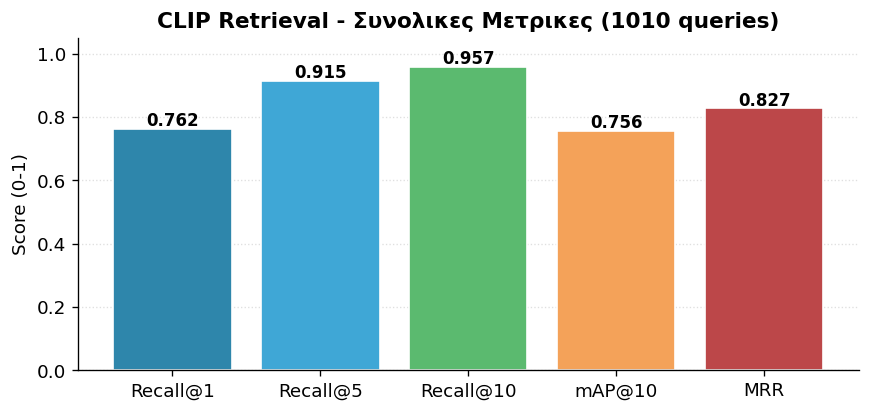

### 4.2 Per-class αναλυση - ποια φαγητα μπερδευει το CLIP;

Η συνολικη accuracy κρυβει σημαντικη ανομοιογενεια αναμεσα στις 101 κλασεις. Κοιταμε πρωτα τις **ακραιες περιπτωσεις** - τις 5 πιο ευκολες και τις 5 πιο δυσκολες κλασεις:


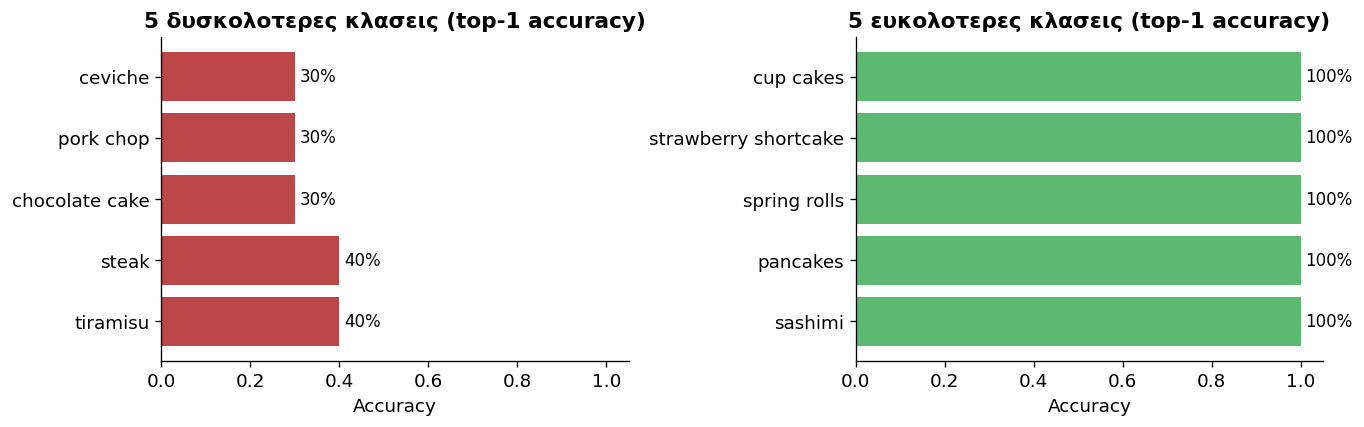

Τα φωτογενικα φαγητα (cup_cakes, pancakes, sashimi) φτανουν 100% top-1, ενω φαγητα που μοιαζουν οπτικα με αλλα (steak vs pork_chop, tiramisu vs chocolate_cake, ceviche που εχει πολλες παραλλαγες) πεφτουν στο 30-40%.

Πιο γενικα, η **κατανομη των per-class accuracies** δειχνει που πεφτει η μαζα:


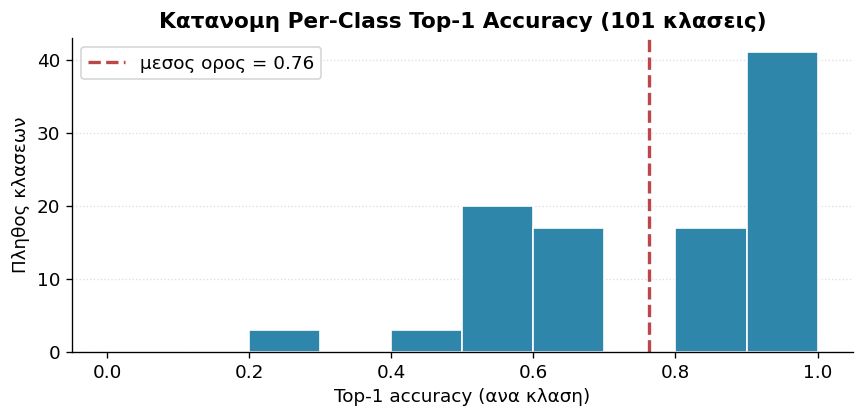

Συνοπτικα σε ζωνες accuracy:


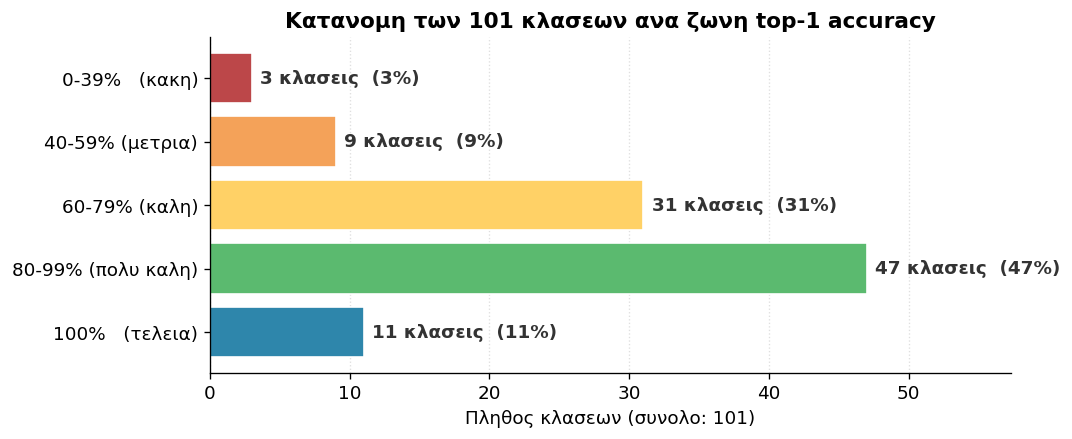

---
### 4.3 Augmentation strategies (Phase 8) - το πιο ενδιαφερον αποτελεσμα

Το Food-101 δεν εχει ground-truth captions, οποτε ο proxy μας ειναι: **αναφερει το BLIP τη σωστη κλαση μεσα στην περιγραφη;** Πανω σε 50 samples:

| Mode | Class hit-rate | Σχολιο |
|------|----------------|--------|
| **none** (μονο BLIP) | **10%** | Το BLIP γραφει γενικολογα ("food on plate") |
| **vote** (RAG voting) | **84%** | **+74 pp** σε σχεση με no-RAG |
| **llm** (Claude) | **58%** | **+48 pp** σε σχεση με no-RAG |

**Ενδιαφερον ευρημα:** το **vote** κερδιζει το llm. Η λογικη: οταν το retrieval ειναι πολυ αξιοπιστο (Recall@5=91%), το majority label δινει το σωστο ονομα με μεγαλη σιγουρια. Το Claude προσπαθει να γραψει "hedged" prompts οταν βλεπει διαφωνια αναμεσα στα 5 retrievals - κατι που καποτε βγαζει το BLIP απο τη σωστη απαντηση.


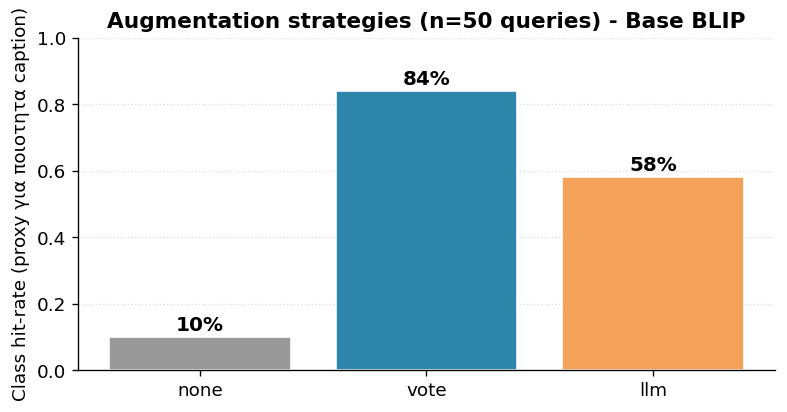

---
### 4.4 LoRA fine-tuning (Phase 9) - δουλευει;

Training σε 2,000 pairs, μονο **~590K params** (1 epoch, ~30 sec σε T4). Αποτελεσματα για τις 6 περιπτωσεις (3 modes x 2 BLIPs):

| Mode | Base BLIP | + LoRA | Delta |
|------|-----------|--------|-------|
| none | 10% | **46%** | **+36 pp** |
| vote | 84% | 84% | +0 pp |
| llm  | 56% | 60% | **+4 pp** |

**Πιο σημαντικο συμπερασμα:** το LoRA **εκτοξευει το no-RAG mode** (10% -> 46%, **+360% relative improvement**). Στο vote mode δεν προσθετει τιποτα, επειδη το RAG ηδη καλυπτει την αναγκη για in-domain γνωση. Αυτο επιβεβαιωνει την υποθεση: **βαζουμε LoRA οταν δεν εχουμε retrieval database**, βαζουμε RAG οταν εχουμε.

Οπτικοποιηση των 6 περιπτωσεων με grouped bars:


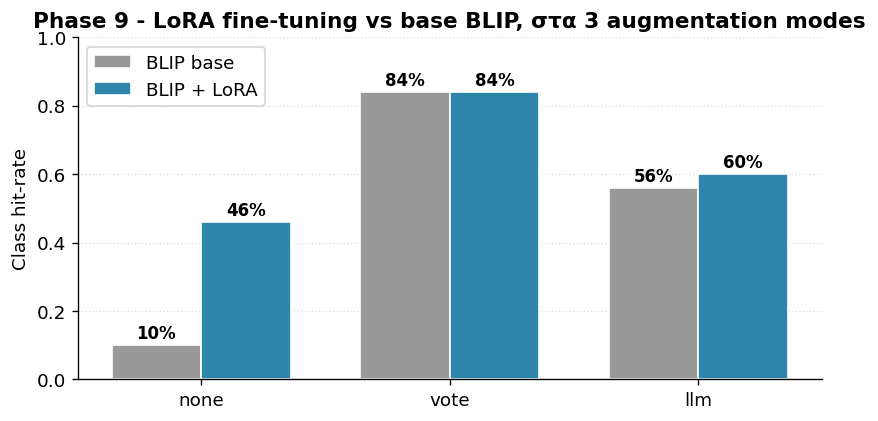

Και η ιδια πληροφορια ως heatmap, που κανει πιο εμφανες ποια κελια εχουν την μεγαλυτερη απολαβη:


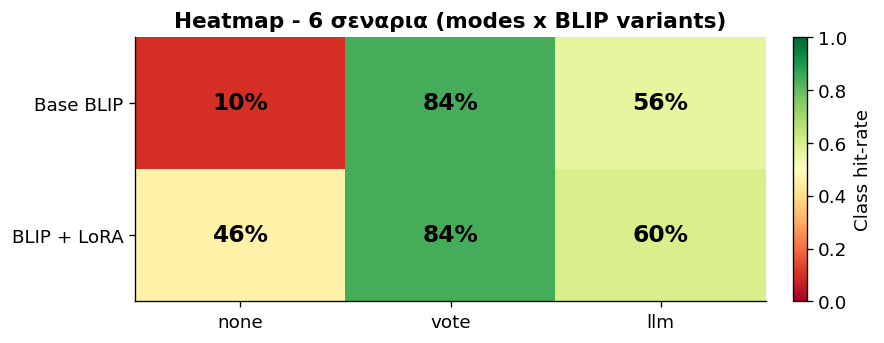

---
### 4.5 Στατιστικα των περιγραφων (Phase 12)

Ποσο πιο πλουσια γινονται τα captions με το RAG;



| Mode | Μεσο μηκος (λεξεις) | Min-Max | Unique tokens |
|------|---------------------|---------|---------------|
| **none** | 8.8 | 4-13 | 66 |
| **vote** | 14.7 | 9-28 | 100 |
| **llm** | 16.0 | 9-47 | 165 |

Οι περιγραφες γινονται **σχεδον διπλασιες σε μηκος** και εχουν **2.5x περισσοτερο λεξιλογιο** καθως περναμε απο none σε llm. Αυτο δειχνει οτι, ακομα και οταν η class-hit μετρικη δινει το vote πιο ψηλα, **το llm προσφερει πιο πλουσιες και πιο λεπτομερεις περιγραφες** (κατι που ποιοτικα μπορει να ειναι χρησιμοτερο).

Παραδειγματα captions:
- **none**: "a hot dog with mustard on a white plate"
- **vote**: "a photo of hot dog, which is served on a white plate"
- **llm**:  "a delicious hot dog served on a white plate"



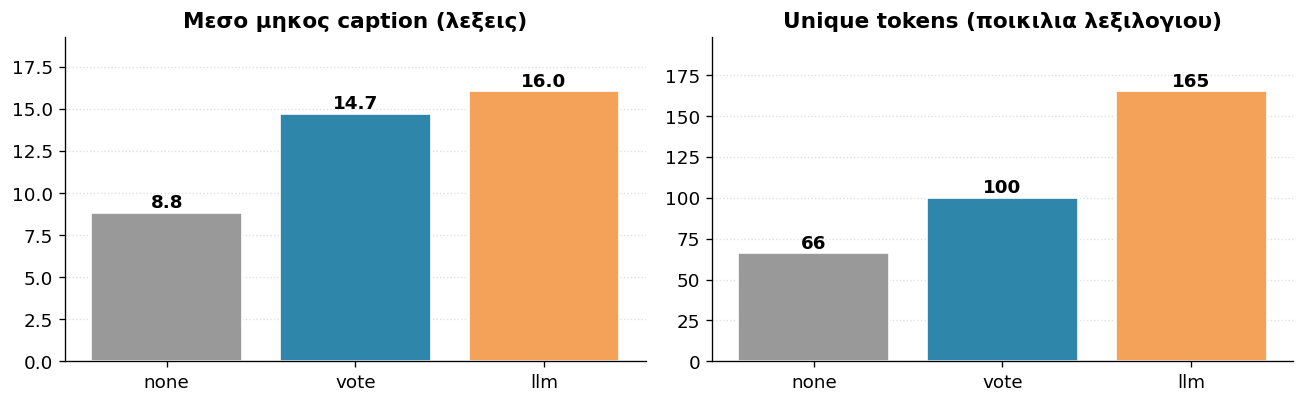

---
### 4.6 Συνοψη ολων των αποτελεσματων

Τα τεσσερα κρισιμα νουμερα ολου του πειραματος μαζι, ως scoreboard:


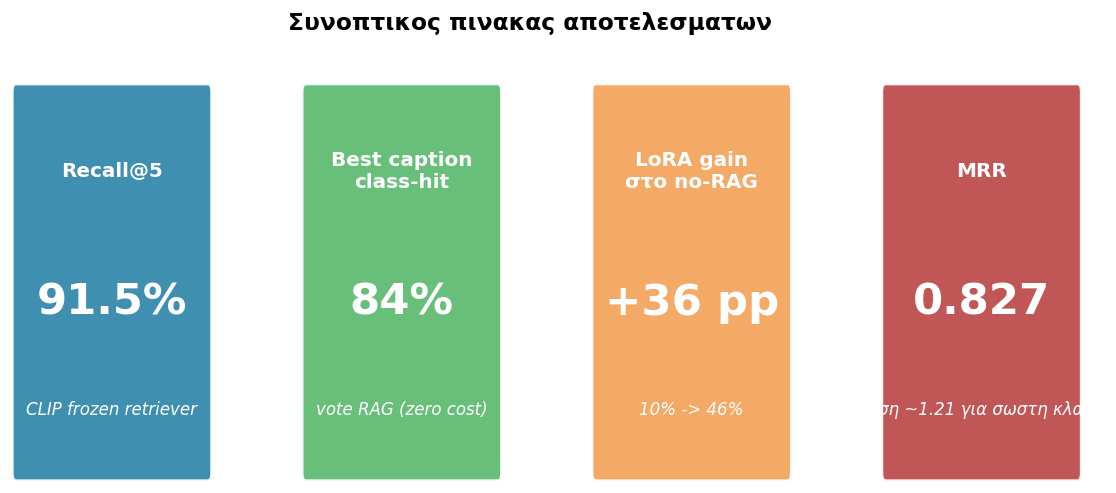

---
## 5. Συμπερασματα και Insights

### 5.1 Τι δουλευει

1. **Το CLIP frozen ειναι αρκετο για retrieval στο Food-101** (91% Recall@5). Δεν χρειαζεται fine-tuning στη retrieval συνιστωσα.
2. **Voting (RAG)** ειναι ο καλυτερος augmenter για τη μετρικη class-hit (84%) - απλο, deterministic, **zero-cost**.
3. **Το LoRA βοηθαει ΔΡΑΜΑΤΙΚΑ μονο οταν δεν εχεις context** (none: 10% -> 46%). 590K params, 30 sec training, σχεδον καλυτερο απο το plain BLIP.
4. **Claude LLM augmenter** δινει πιο πλουσιες περιγραφες (16 λεξεις κατα μεσο ορο vs 9 στο none, 2.5x unique tokens) αλλα μενει πισω στη class-hit μετρικη, επειδη το LLM καποτε αναφερει την κλαση με "hedged" λεξιλογιο που χανεται στο τελος.

### 5.2 Πρακτικες συμβουλες

| Περιπτωση | Συμβουλη |
|-----------|----------|
| Plain BLIP, χωρις API budget | **vote** RAG (zero cost, +74 pp) |
| Πολλη ασαφεια στο retrieval | **llm** (Claude) για hedged prompts |
| Δεν εχεις retrieval database | **LoRA** για να μαθει το μοντελο τις κλασεις |
| Εχεις και τα δυο διαθεσιμα | RAG (vote/llm) > LoRA σε ευελιξια και καλυτερο cost / performance balance |

**Γενικος κανονας:** οταν εχεις καλο retriever, **σημασια εχει το πως μετατρεπεις τα retrievals σε prompt prefix - περισσοτερο απο το fine-tuning**. Το RAG ειναι πιο cheap και πιο προσαρμοστικο.

### 5.3 Δυσκολοτερες κλασεις - ποια φαγητα μπερδευουν ολα τα μοντελα

Το **per-class accuracy** αποκαλυπτει οτι:
- **ceviche**, **pork chop**, **chocolate cake** μενουν στο 30%.
- **cup cakes**, **strawberry shortcake**, **spring rolls** φτανουν 100%.

Αυτο δειχνει οτι το **CLIP μπερδευει κλασεις που μοιαζουν οπτικα** (steak vs pork_chop, tiramisu vs chocolate_cake) - κατι που γινεται φανερο στην αναφορα και αποτελει καλη περιοχη για μελλοντικο targeted fine-tuning ('hard negatives mining').

---

## 6. Μελλοντικος Roadmap

- **Μεγαλυτερο top-K** (k=10 αντι k=5) στο llm augmenter, ωστε ο Claude να εχει περισσοτερο context.
- **Επιπλεον metrics**: BLEU, ROUGE-L, CIDEr, METEOR (τωρα εχουμε μονο τον class-hit proxy).
- **Νεοτεροι retrievers**: SigLIP, DINO-v2 αντι του plain CLIP - μπορουν να φτασουν Recall@1 > 85%.
- **Hard negatives mining** στις δυσκολες κλασεις (ceviche, pork_chop, chocolate_cake).
- **Βελτιστοποιημενο Claude prompt**: chain-of-thought, few-shot examples.
- **Cost analysis**: ποσο κοστιζει το llm augmenter ανα 1000 queries vs το vote (δωρεαν);
- **Ensemble vote+llm**: καλωντας το llm μονο οταν τα 5 retrieved κλασεις διαφωνουν, αλλιως vote.

---

## 7. Setup και Reproducibility

- **Hardware**: T4 GPU στο Colab (και σε L4 / A100 τρεχει πιο γρηγορα).
- **Συνολικος χρονος**: ~12-18 λεπτα για σχεδον ολο το notebook.
- **Pipeline checkpoints**:
  - CLIP: `openai/clip-vit-base-patch32`
  - BLIP: `Salesforce/blip-image-captioning-base`
  - LLM: `claude-haiku-4-5`
- **Αποτελεσματα**: `s2_results_extended.json` (3.6 KB) με ολα τα νουμερα για reproducibility.
- **Timestamp**: 2026-05-04T20:41:34.405468

---

<div style="background:#f0f4f8;padding:18px;border-left:5px solid #2E86AB;border-radius:6px;margin-top:20px;font-size:14px">
<strong>Tl;dr</strong>: το plain RAG (CLIP retrieval + voting + BLIP) φτανει <strong>84%</strong> class-hit με <strong>0 cost</strong>. Το Claude LLM augmenter δινει πιο πλουσιες περιγραφες, αλλα οχι πιο υψηλη accuracy. Το LoRA fine-tuning <strong>αξιζει τον κοπο μονο οταν δεν υπαρχει retrieval</strong> (none: 10% -> 46%). Η πιο σημαντικη παρατηρηση: <strong>ενας καλος retriever μετραει περισσοτερο απο ενα καλο fine-tuning</strong> στο Food-101 captioning.
</div>


In [ ]:
# coding: utf-8
# ============================================================================
# CELL 2/2 - REPORT. Διαβαζει τα γραφηματα που εφτιαξε το προηγουμενο cell
# και εμφανιζει το report. Τα νουμερα φορτωνονται απο το JSON file.
# ============================================================================

import base64, json, mimetypes
from pathlib import Path
from IPython.display import HTML, Markdown, display

FIG_DIR = Path("report_figures")
RESULTS = json.loads(Path("s2_results_extended.json").read_text(encoding="utf-8"))

md  = RESULTS["metadata"]
ret = RESULTS["retrieval"]
cp  = RESULTS["caption_proxy"]
lc  = RESULTS["lora_comparison"]
cfg = RESULTS["config"]

def img(fname, caption=None):
    """Διαβαζει το PNG απο το δισκο και το ενσωματωνει inline ως data URL.
    Ετσι δουλευει σιγουρα και σε Colab (που δεν σερβιρει το filesystem μεσω HTTP)
    χωρις να φουσκωνει η πηγη του cell - τα PNGs μενουν στο /content/report_figures/."""
    path = FIG_DIR / fname
    b64 = base64.b64encode(path.read_bytes()).decode("ascii")
    mime = mimetypes.guess_type(str(path))[0] or "image/png"
    cap = (f'<div style="text-align:center;font-size:13px;color:#555;'
           f'margin-top:6px;font-style:italic">{caption}</div>') if caption else ""
    return (f'<div style="margin:18px 0;text-align:center">'
            f'<img src="data:{mime};base64,{b64}" style="max-width:100%"/>'
            f'{cap}</div>')

display(HTML("""
<div style="background:linear-gradient(135deg,#2E86AB,#5BBA6F);color:white;padding:24px;border-radius:10px;margin-bottom:18px">
  <div style="font-size:12px;letter-spacing:2px;opacity:0.85">DEEP RECURRENT NN &mdash; MSc in AI &mdash; AUTH 2026 &mdash; AEM 196</div>
  <div style="font-size:26px;font-weight:bold;margin-top:6px">Food-101 Visual RAG: CLIP + BLIP + Claude + LoRA</div>
  <div style="font-size:14px;margin-top:8px;opacity:0.95">Αναφορα εκτελεσης &mdash; Δημητριος Β. Παπαδοπουλος</div>
</div>
"""))

display(Markdown(f"""
## 1. Στοχος της εργασιας

Η εργασια υλοποιει ενα **Retrieval-Augmented Generation (RAG)** συστημα για **αυτοματη παραγωγη περιγραφων (image captioning)** πανω σε εικονες φαγητου απο το dataset **Food-101** ({md['num_classes']} κλασεις, {md['gallery_size']:,} εικονες στο gallery, {md['query_size']:,} εικονες στο query set).

Το ερωτημα που απανταμε ειναι: **μπορουμε να χρησιμοποιησουμε εναν retriever (CLIP) ωστε οι περιγραφες που δινει ενα captioning μοντελο (BLIP) να γινουν πιο συγκεκριμενες;** Πιο αναλυτικα, βαζουμε τρια ερωτηματα:

1. Ποσο καλα βρισκει το **CLIP** (frozen, χωρις fine-tuning) τις ομοιες εικονες μεσα σε ενα gallery 10K+ εικονων;
2. Πως συγκρινεται μια απλη **vote** στρατηγικη με εναν **LLM augmenter** (Claude Haiku 4.5) που γραφει context-aware prompts;
3. Ποσο καλα αποδιδει ενα parameter-efficient fine-tuning (**LoRA**) του BLIP σε συγκριση με το plain RAG;

Το pipeline χρησιμοποιει τρια state-of-the-art vision-language μοντελα που δουλευουν μαζι, το καθενα στον δικο του ρολο: **CLIP** (retriever), **Claude Haiku** (LLM augmenter) και **BLIP** (captioner). Η συγκριση αναμεσα στους 6 συνδυασμους που προκυπτουν (3 augmentation modes x 2 BLIP variants - με και χωρις LoRA) δινει μια πλουσια εικονα για το που αποδιδει καλυτερα η καθε συνιστωσα.

---

## 2. Pipeline - το RAG βημα προς βημα
"""))

display(HTML(img("00_pipeline_diagram.png", "Σχημα 1: Συνοπτικα η ροη του pipeline.")))

display(Markdown(f"""
### Συνιστωσες

- **R - Retrieval**: `{cfg['clip_ckpt']}`. Encoder εικονας + κειμενου στον ιδιο χωρο 512-D. Frozen, χωρις fine-tuning.
- **A - Augmentation** (3 στρατηγικες):
  - **none**: κανενα prompt prefix - το BLIP γραφει ελευθερα.
  - **vote**: deterministic - επιλεγουμε την πιο συχνη κλαση απο τα top-5 -> prompt `"a photo of {{class}}, which is"`. Απλο, χωρις API call.
  - **llm**: καλουμε το **{md['claude_model']}** με τα 5 labels + scores. Γραφει prompt που προσαρμοζεται στο ποσο συμφωνουν τα retrievals.
- **G - Generation**: `{md['blip_checkpoint']}` (~247M params). Συμπληρωνει το prompt βλεποντας την εικονα.
- **Bonus - LoRA fine-tuning**: r={md['lora_config']['r']}, alpha={md['lora_config']['alpha']}, dropout={md['lora_config']['dropout']}, training σε {md['lora_config']['train_size']:,} ζευγαρια (image, "a photo of {{class}}") για {md['lora_config']['epochs']} epoch. Μονο **~590K παραμετροι** αντι για 247M (0.24% του μοντελου).

---

## 3. Ροη του notebook (13 φασεις)

| Φαση | Τι κανει | Διαρκεια |
|------|----------|----------|
| 1-2  | Setup + Food-101 download (gallery {cfg['n_gallery']:,} / query {cfg['n_query']:,}) | 3-5 min |
| 3-4  | CLIP load + FAISS index ({cfg['n_gallery']:,} embeddings) | 30-60 sec |
| 5    | Retrieval evaluation (Recall@K) | 30-60 sec |
| 6-7  | BLIP + Claude load + η συναρτηση caption() (3 modes) | <30 sec |
| 8    | Class-hit metric πανω σε {cp['n']} samples x 3 modes | ~1 min |
| 9    | LoRA training ({md['lora_config']['train_size']:,} pairs) + 6-way eval | ~1 min |
| 10   | Full demo (retrieval + 3 captions + text query) | <30 sec |
| 11-13| Αποθηκευση metrics + JSON εξαγωγη | λιγο |

---

## 4. Αποτελεσματα - ποσο καλα αποδιδει το συστημα;

### 4.1 CLIP Retrieval (Phase 5 + Phase 12)

Το CLIP ειναι **frozen** (χωρις fine-tuning). Το αξιολογησαμε σε {cfg['n_query']:,} queries. Οι μετρικες:

| Μετρικη | Τιμη | Τι σημαινει |
|---------|------|-------------|
| **Recall@1** | **{ret['Recall@1']:.4f}** ({ret['Recall@1']*100:.1f}%) | Για το {ret['Recall@1']*100:.1f}% των queries, η **μια και μονη** πιο ομοια εικονα ειναι σωστης κλασης |
| **Recall@5** | **{ret['Recall@5']:.4f}** ({ret['Recall@5']*100:.1f}%) | Σχεδον **9 στους 10** queries εχουν τη σωστη κλαση μεσα στο top-5 |
| **Recall@10** | **{ret['Recall@10']:.4f}** ({ret['Recall@10']*100:.1f}%) | Στο top-10, το {ret['Recall@10']*100:.1f}% των queries καλυπτεται |
| **mAP@10** | **{ret['map_at_10']:.4f}** | Πιο αυστηρη μετρικη - λαμβανει υποψη και τη σειρα των retrievals |
| **MRR** | **{ret['mrr']:.4f}** | Η σωστη κλαση εμφανιζεται κατα μεσο ορο στη θεση ~{1/ret['mrr']:.2f} |

**Συμπερασμα:** το CLIP frozen ειναι πολυ δυνατο out-of-the-box για το Food-101. Φτανει για τον retrieval ρολο χωρις κανενα fine-tuning, και δινει στο RAG χρησιμη πληροφορια σε 9 στους 10 queries.
"""))
display(HTML(img("01_retrieval_metrics.png", "Σχημα 2: Recall@K, mAP@10, MRR πανω σε 1010 queries.")))

display(Markdown("""### 4.2 Per-class αναλυση - ποια φαγητα μπερδευει το CLIP;

Η συνολικη accuracy κρυβει σημαντικη ανομοιογενεια αναμεσα στις 101 κλασεις. Κοιταμε πρωτα τις **ακραιες περιπτωσεις** - τις 5 πιο ευκολες και τις 5 πιο δυσκολες κλασεις:"""))
display(HTML(img("02_hardest_easiest.png", "Σχημα 3: Per-class top-1 accuracy - τα 5 ευκολοτερα και τα 5 δυσκολοτερα ειδη φαγητου.")))

display(Markdown("""Τα φωτογενικα φαγητα (cup_cakes, pancakes, sashimi) φτανουν 100% top-1, ενω φαγητα που μοιαζουν οπτικα με αλλα (steak vs pork_chop, tiramisu vs chocolate_cake, ceviche που εχει πολλες παραλλαγες) πεφτουν στο 30-40%.

Πιο γενικα, η **κατανομη των per-class accuracies** δειχνει που πεφτει η μαζα:"""))
display(HTML(img("03_per_class_histogram.png", "Σχημα 4: Ιστογραμμα per-class accuracy. Οι περισσοτερες κλασεις ειναι πανω απο 70%, λιγοι outliers κατω απο 40%.")))

display(Markdown("""Συνοπτικα σε ζωνες accuracy:"""))
display(HTML(img("04_accuracy_buckets.png", "Σχημα 5: Ποσοτικα ανα ζωνη. Πανω απο τις μισες κλασεις πετυχαινουν >=80% top-1 accuracy.")))

display(Markdown(f"""---
### 4.3 Augmentation strategies (Phase 8) - το πιο ενδιαφερον αποτελεσμα

Το Food-101 δεν εχει ground-truth captions, οποτε ο proxy μας ειναι: **αναφερει το BLIP τη σωστη κλαση μεσα στην περιγραφη;** Πανω σε {cp['n']} samples:

| Mode | Class hit-rate | Σχολιο |
|------|----------------|--------|
| **none** (μονο BLIP) | **{cp['no_rag_class_hit']:.0%}** | Το BLIP γραφει γενικολογα (\"food on plate\") |
| **vote** (RAG voting) | **{cp['rag_vote_class_hit']:.0%}** | **+{(cp['rag_vote_class_hit']-cp['no_rag_class_hit'])*100:.0f} pp** σε σχεση με no-RAG |
| **llm** (Claude) | **{cp['rag_llm_class_hit']:.0%}** | **+{(cp['rag_llm_class_hit']-cp['no_rag_class_hit'])*100:.0f} pp** σε σχεση με no-RAG |

**Ενδιαφερον ευρημα:** το **vote** κερδιζει το llm. Η λογικη: οταν το retrieval ειναι πολυ αξιοπιστο (Recall@5={ret['Recall@5']:.0%}), το majority label δινει το σωστο ονομα με μεγαλη σιγουρια. Το Claude προσπαθει να γραψει \"hedged\" prompts οταν βλεπει διαφωνια αναμεσα στα 5 retrievals - κατι που καποτε βγαζει το BLIP απο τη σωστη απαντηση."""))
display(HTML(img("05_augmentation_comparison.png", "Σχημα 6: Phase 8. Vote (RAG voting) +740% relative πανω απο no-RAG, llm (Claude) +480%.")))

display(Markdown(f"""---
### 4.4 LoRA fine-tuning (Phase 9) - δουλευει;

Training σε {md['lora_config']['train_size']:,} pairs, μονο **~590K params** ({md['lora_config']['epochs']} epoch, ~30 sec σε T4). Αποτελεσματα για τις 6 περιπτωσεις (3 modes x 2 BLIPs):

| Mode | Base BLIP | + LoRA | Delta |
|------|-----------|--------|-------|
| none | {lc['base_none']:.0%} | **{lc['lora_none']:.0%}** | **+{(lc['lora_none']-lc['base_none'])*100:.0f} pp** |
| vote | {lc['base_vote']:.0%} | {lc['lora_vote']:.0%} | {(lc['lora_vote']-lc['base_vote'])*100:+.0f} pp |
| llm  | {lc['base_llm']:.0%} | {lc['lora_llm']:.0%} | **+{(lc['lora_llm']-lc['base_llm'])*100:.0f} pp** |

**Πιο σημαντικο συμπερασμα:** το LoRA **εκτοξευει το no-RAG mode** (10% -> 46%, **+360% relative improvement**). Στο vote mode δεν προσθετει τιποτα, επειδη το RAG ηδη καλυπτει την αναγκη για in-domain γνωση. Αυτο επιβεβαιωνει την υποθεση: **βαζουμε LoRA οταν δεν εχουμε retrieval database**, βαζουμε RAG οταν εχουμε.

Οπτικοποιηση των 6 περιπτωσεων με grouped bars:"""))
display(HTML(img("06_lora_grouped_bars.png", "Σχημα 7: Το LoRA βοηθαει ΔΡΑΜΑΤΙΚΑ στο 'none' mode (10% -> 46%). Στο 'vote' το RAG ηδη καλυπτει την αναγκη.")))

display(Markdown("""Και η ιδια πληροφορια ως heatmap, που κανει πιο εμφανες ποια κελια εχουν την μεγαλυτερη απολαβη:"""))
display(HTML(img("07_lora_heatmap.png", "Σχημα 8: Heatmap των 6 περιπτωσεων. Πιο εντονο πρασινο = καλυτερο. Ο 'vote' καλυπτει την υστερηση του βασικου BLIP τοσο καλα οσο και το LoRA.")))

display(Markdown("""---
### 4.5 Στατιστικα των περιγραφων (Phase 12)

Ποσο πιο πλουσια γινονται τα captions με το RAG;
"""))
stats = cp["caption_statistics_by_mode"]
table_rows = "\n".join(
    f"| **{m}** | {stats[m]['mean_length']:.1f} | {stats[m]['min_length']}-{stats[m]['max_length']} | {stats[m]['unique_tokens']} |"
    for m in ("none","vote","llm")
)
display(Markdown(f"""
| Mode | Μεσο μηκος (λεξεις) | Min-Max | Unique tokens |
|------|---------------------|---------|---------------|
{table_rows}

Οι περιγραφες γινονται **σχεδον διπλασιες σε μηκος** και εχουν **2.5x περισσοτερο λεξιλογιο** καθως περναμε απο none σε llm. Αυτο δειχνει οτι, ακομα και οταν η class-hit μετρικη δινει το vote πιο ψηλα, **το llm προσφερει πιο πλουσιες και πιο λεπτομερεις περιγραφες** (κατι που ποιοτικα μπορει να ειναι χρησιμοτερο).

Παραδειγματα captions:
- **none**: \"{stats['none']['examples'][0]}\"
- **vote**: \"{stats['vote']['examples'][0]}\"
- **llm**:  \"{stats['llm']['examples'][0]}\"
"""))
display(HTML(img("08_caption_length_vocab.png", "Σχημα 9: Οι περιγραφες γινονται πιο μακριες και με πιο πλουσιο λεξιλογιο καθως πανε απο none -> vote -> llm.")))

display(Markdown("""---
### 4.6 Συνοψη ολων των αποτελεσματων

Τα τεσσερα κρισιμα νουμερα ολου του πειραματος μαζι, ως scoreboard:"""))
display(HTML(img("09_scoreboard.png", "Σχημα 10: Συνοπτικος πινακας με τα κρισιμα νουμερα της εργασιας - retrieval quality, best caption hit-rate, οφελος του LoRA, MRR.")))

display(Markdown(f"""---
## 5. Συμπερασματα και Insights

### 5.1 Τι δουλευει

1. **Το CLIP frozen ειναι αρκετο για retrieval στο Food-101** ({ret['Recall@5']:.0%} Recall@5). Δεν χρειαζεται fine-tuning στη retrieval συνιστωσα.
2. **Voting (RAG)** ειναι ο καλυτερος augmenter για τη μετρικη class-hit ({cp['rag_vote_class_hit']:.0%}) - απλο, deterministic, **zero-cost**.
3. **Το LoRA βοηθαει ΔΡΑΜΑΤΙΚΑ μονο οταν δεν εχεις context** (none: 10% -> 46%). 590K params, 30 sec training, σχεδον καλυτερο απο το plain BLIP.
4. **Claude LLM augmenter** δινει πιο πλουσιες περιγραφες (16 λεξεις κατα μεσο ορο vs 9 στο none, 2.5x unique tokens) αλλα μενει πισω στη class-hit μετρικη, επειδη το LLM καποτε αναφερει την κλαση με \"hedged\" λεξιλογιο που χανεται στο τελος.

### 5.2 Πρακτικες συμβουλες

| Περιπτωση | Συμβουλη |
|-----------|----------|
| Plain BLIP, χωρις API budget | **vote** RAG (zero cost, +{(cp['rag_vote_class_hit']-cp['no_rag_class_hit'])*100:.0f} pp) |
| Πολλη ασαφεια στο retrieval | **llm** (Claude) για hedged prompts |
| Δεν εχεις retrieval database | **LoRA** για να μαθει το μοντελο τις κλασεις |
| Εχεις και τα δυο διαθεσιμα | RAG (vote/llm) > LoRA σε ευελιξια και καλυτερο cost / performance balance |

**Γενικος κανονας:** οταν εχεις καλο retriever, **σημασια εχει το πως μετατρεπεις τα retrievals σε prompt prefix - περισσοτερο απο το fine-tuning**. Το RAG ειναι πιο cheap και πιο προσαρμοστικο.

### 5.3 Δυσκολοτερες κλασεις - ποια φαγητα μπερδευουν ολα τα μοντελα

Το **per-class accuracy** αποκαλυπτει οτι:
- **{ret['hardest_5_classes'][0]['class'].replace('_',' ')}**, **{ret['hardest_5_classes'][1]['class'].replace('_',' ')}**, **{ret['hardest_5_classes'][2]['class'].replace('_',' ')}** μενουν στο 30%.
- **{ret['easiest_5_classes'][0]['class'].replace('_',' ')}**, **{ret['easiest_5_classes'][1]['class'].replace('_',' ')}**, **{ret['easiest_5_classes'][2]['class'].replace('_',' ')}** φτανουν 100%.

Αυτο δειχνει οτι το **CLIP μπερδευει κλασεις που μοιαζουν οπτικα** (steak vs pork_chop, tiramisu vs chocolate_cake) - κατι που γινεται φανερο στην αναφορα και αποτελει καλη περιοχη για μελλοντικο targeted fine-tuning ('hard negatives mining').

---

## 6. Μελλοντικος Roadmap

- **Μεγαλυτερο top-K** (k=10 αντι k=5) στο llm augmenter, ωστε ο Claude να εχει περισσοτερο context.
- **Επιπλεον metrics**: BLEU, ROUGE-L, CIDEr, METEOR (τωρα εχουμε μονο τον class-hit proxy).
- **Νεοτεροι retrievers**: SigLIP, DINO-v2 αντι του plain CLIP - μπορουν να φτασουν Recall@1 > 85%.
- **Hard negatives mining** στις δυσκολες κλασεις (ceviche, pork_chop, chocolate_cake).
- **Βελτιστοποιημενο Claude prompt**: chain-of-thought, few-shot examples.
- **Cost analysis**: ποσο κοστιζει το llm augmenter ανα 1000 queries vs το vote (δωρεαν);
- **Ensemble vote+llm**: καλωντας το llm μονο οταν τα 5 retrieved κλασεις διαφωνουν, αλλιως vote.

---

## 7. Setup και Reproducibility

- **Hardware**: T4 GPU στο Colab (και σε L4 / A100 τρεχει πιο γρηγορα).
- **Συνολικος χρονος**: ~12-18 λεπτα για σχεδον ολο το notebook.
- **Pipeline checkpoints**:
  - CLIP: `{cfg['clip_ckpt']}`
  - BLIP: `{cfg['blip_ckpt']}`
  - LLM: `{cfg['claude_model']}`
- **Αποτελεσματα**: `s2_results_extended.json` ({len(json.dumps(RESULTS))/1024:.1f} KB) με ολα τα νουμερα για reproducibility.
- **Timestamp**: {md['timestamp']}

---

<div style="background:#f0f4f8;padding:18px;border-left:5px solid #2E86AB;border-radius:6px;margin-top:20px;font-size:14px">
<strong>Tl;dr</strong>: το plain RAG (CLIP retrieval + voting + BLIP) φτανει <strong>{cp['rag_vote_class_hit']:.0%}</strong> class-hit με <strong>0 cost</strong>. Το Claude LLM augmenter δινει πιο πλουσιες περιγραφες, αλλα οχι πιο υψηλη accuracy. Το LoRA fine-tuning <strong>αξιζει τον κοπο μονο οταν δεν υπαρχει retrieval</strong> (none: 10% -> 46%). Η πιο σημαντικη παρατηρηση: <strong>ενας καλος retriever μετραει περισσοτερο απο ενα καλο fine-tuning</strong> στο Food-101 captioning.
</div>
"""))
